In [ ]:
Iris Flower Classification

In this notebook I am building a machine learning model to classify Iris flowers into 3 species based on their measurements using Random Forest Classifier.

Dataset: 150 samples | Features: 4 | Model: Random Forest

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("All Libraries Imported Successfully")

All Libraries Imported Successfully


In [5]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")
df.head()

Total Rows: 150
Total Columns: 5


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [6]:
print(df['species'].value_counts())
print()
df.describe()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


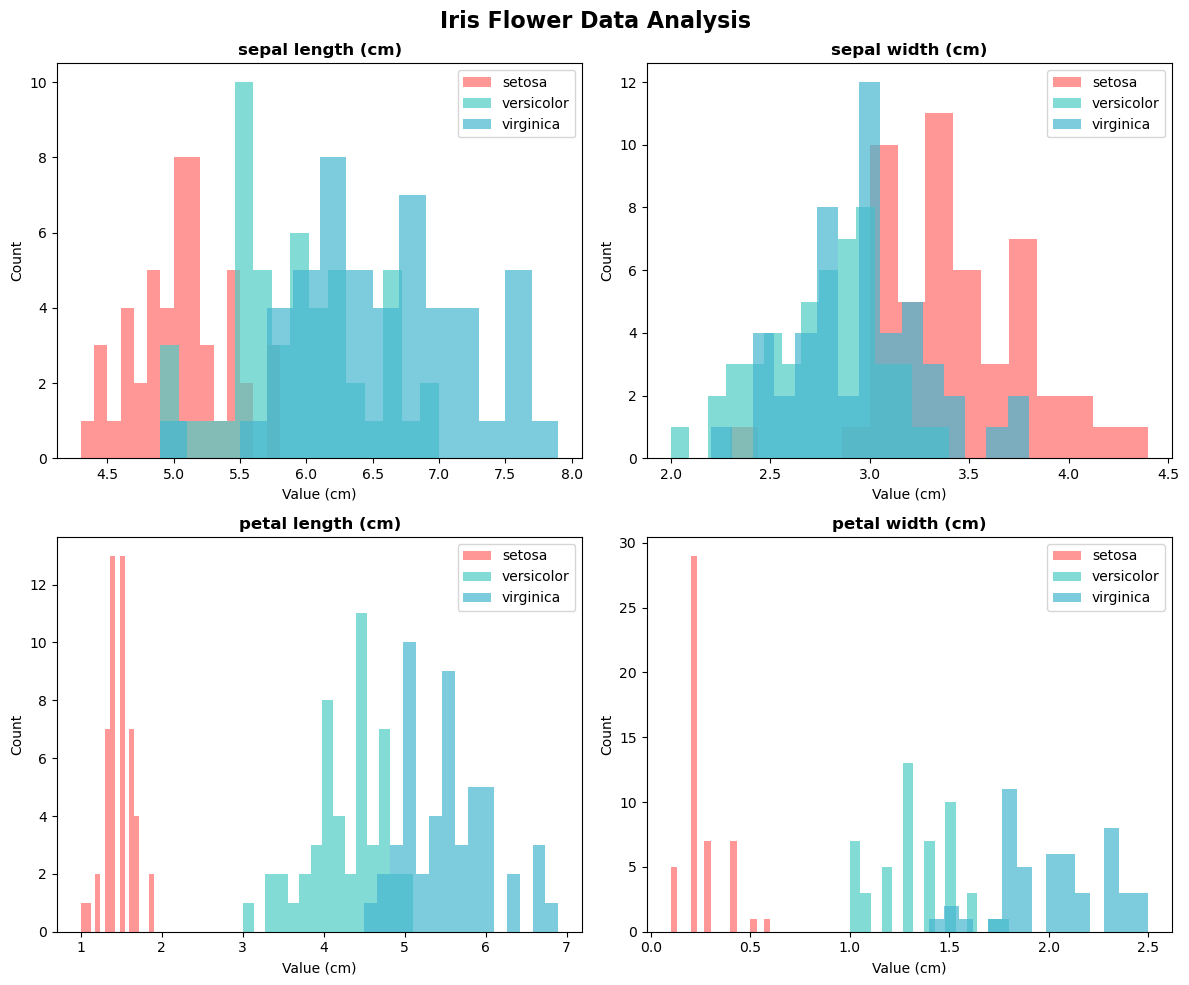

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Iris Flower Data Analysis', fontsize=16, fontweight='bold')

features = iris.feature_names
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1']

for idx, feature in enumerate(features[:4]):
    ax = axes[idx//2][idx%2]
    for i, species in enumerate(iris.target_names):
        data = df[df['species'] == species][feature]
        ax.hist(data, alpha=0.7, label=species, color=colors[i], bins=15)
    ax.set_title(feature, fontweight='bold')
    ax.set_xlabel('Value (cm)')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.savefig('iris_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
X = df[iris.feature_names]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print(f"Training Samples: {X_train.shape[0]}")
print(f"Testing Samples: {X_test.shape[0]}")
print("Model Trained Successfully")

Training Samples: 120
Testing Samples: 30
Model Trained Successfully


Model Accuracy: 100.00%

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



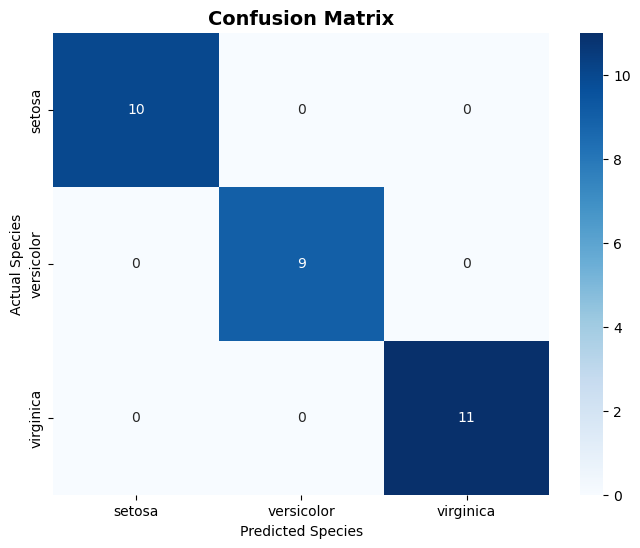

In [9]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")
print()
print(classification_report(y_test, y_pred, target_names=iris.target_names))

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual Species')
plt.xlabel('Predicted Species')
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
test_flowers = [
    [5.1, 3.5, 1.4, 0.2],
    [6.3, 3.3, 4.7, 1.6],
    [6.5, 3.0, 5.5, 1.8],
]

for i, flower in enumerate(test_flowers):
    prediction = model.predict([flower])
    species = iris.target_names[prediction[0]]
    print(f"Flower {i+1}: {flower} --> Predicted Species: {species.upper()}")

Flower 1: [5.1, 3.5, 1.4, 0.2] --> Predicted Species: SETOSA
Flower 2: [6.3, 3.3, 4.7, 1.6] --> Predicted Species: VERSICOLOR
Flower 3: [6.5, 3.0, 5.5, 1.8] --> Predicted Species: VIRGINICA
